In [58]:
import pandas as pd
import numpy as np
import re
from textblob import TextBlob
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px
import kaggle
from kagglehub import KaggleDatasetAdapter
from kaggle.api.kaggle_api_extended import KaggleApi

### Load dataset

Dataset initially gathered from multiple sources but due to issues with previous datasets, I decided to use just a combined dataset from Kaggle that has clean location information including Province. The downside is that this just covered 6 metro areas

In [59]:
# #uncomment below to redownload
# # Set the path where you want to save the downloaded file
# download_path = "../data"
# #source = 'jiashenliu/515k-hotel-reviews-data-in-europe'
# source = 'huypui/data-515k-rating-hotel' #with province (city)
# # Download the dataset using kaggle API
# kaggle.api.dataset_download_files(source, path=download_path, unzip=True)

In [60]:
# Now load the CSV file using pandas
file_path = "../data/Hotel_Reviews.csv" 
df = pd.read_csv(file_path)
df = df.sample(100000, random_state=42) # For testing locally
df.head()

,Id_Hotel_Rating,Hotel_Address,Province_Name,Country_Name,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
488440,488441,Via Senigallia 6 20161,Milan,Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,9.6,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
274649,274650,Arlandaweg 10 Westpoort 1043 EW,Amsterdam,Netherlands,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,8.8,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443
374688,374689,Mallorca 251 Eixample 08008,Barcelona,Spain,46,11/26/2015,8.3,Alexandra Barcelona A DoubleTree by Hilton,Sweden,Pillows,3,351,Nice welcoming and service,5,15,7.9,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,2.161520
404352,404353,Piazza Della Repubblica 17 Central Station 20124,Milan,Italy,241,10/17/2015,9.1,Hotel Principe Di Savoia,United States of America,No Negative,0,1543,Everything including the nice upgrade The Hot...,27,9,10.0,"[' Leisure trip ', ' Couple ', ' Ambassador Ju...",656 day,45.479888,9.196298
451596,451597,Singel 303 309 Amsterdam City Center 1012 WJ,Amsterdam,Netherlands,834,5/16/2016,9.1,Hotel Esther a,United Kingdom,No Negative,0,4687,Lovely hotel v welcoming staff,7,2,9.6,"[' Business trip ', ' Solo traveler ', ' Class...",444 day,52.370545,4.888644


In [61]:
# Check coverage
df['Province_Name'].unique().tolist()

['Milan ', 'Amsterdam ', 'Barcelona ', 'London', 'Paris ', 'Vienna ']

In [62]:
# Province_Name is actually Metro_Area so renaming that column

df.rename(columns={'Province_Name': 'Metro_Area'}, inplace=True)

# Remove Trailing Whitespace
df["Metro_Area"] = df["Metro_Area"].str.strip()
df['Metro_Area'].unique().tolist()

['Milan', 'Amsterdam', 'Barcelona', 'London', 'Paris', 'Vienna']

In [63]:
df.groupby("Metro_Area")[['lat', 'lng']].nunique()

,lat,lng
Metro_Area,,
Amsterdam,105,105
Barcelona,208,208
London,397,397
Milan,160,160
Paris,454,454
Vienna,147,147


### EDA, data cleaning, and feature engineering

In [64]:
# Keep only columns that are needed

df = df[[
    "Hotel_Name",
    "Hotel_Address",
    "Reviewer_Score",
    "Total_Number_of_Reviews",
    "Positive_Review",
    "Negative_Review",
    "lat",
    "lng",
    "Metro_Area"
]].copy()

#df.dropna(subset=["Positive_Review", "Negative_Review", "lat", "lng"], how="all", inplace=True)
df.dropna(subset=["Positive_Review", "Negative_Review"], how="all", inplace=True)
df.head()

,Hotel_Name,Hotel_Address,Reviewer_Score,Total_Number_of_Reviews,Positive_Review,Negative_Review,lat,lng,Metro_Area
488440,Hotel Da Vinci,Via Senigallia 6 20161,9.6,16670,Hotel was great clean friendly staff free bre...,Would have appreciated a shop in the hotel th...,45.533137,9.171102,Milan
274649,Urban Lodge Hotel,Arlandaweg 10 Westpoort 1043 EW,8.8,5018,No Positive,No tissue paper box was present at the room,52.385649,4.834443,Amsterdam
374688,Alexandra Barcelona A DoubleTree by Hilton,Mallorca 251 Eixample 08008,7.9,351,Nice welcoming and service,Pillows,41.393192,2.161520,Barcelona
404352,Hotel Principe Di Savoia,Piazza Della Repubblica 17 Central Station 20124,10.0,1543,Everything including the nice upgrade The Hot...,No Negative,45.479888,9.196298,Milan
451596,Hotel Esther a,Singel 303 309 Amsterdam City Center 1012 WJ,9.6,4687,Lovely hotel v welcoming staff,No Negative,52.370545,4.888644,Amsterdam


***Per data analysis, extracting actual city name from address will not be an efficient clean effort so due to time contraints, I have decided to use Metro_Area as a city. Extracting actual city using lat/long may be useful in a future iteration.***

In [65]:
df["city"] = df["Metro_Area"]
df["city"].value_counts()

city
London       50791
Paris        11675
Barcelona    11673
Amsterdam    10982
Vienna        7585
Milan         7294
Name: count, dtype: int64

In [66]:
sorted(df["city"].dropna().unique())

['Amsterdam', 'Barcelona', 'London', 'Milan', 'Paris', 'Vienna']

### Sentiment analysis

Traditional sentiment analysis produces a single overall sentiment score for an entire review. However, hotel reviews often contain mixed opinions. For example, a guest may praise the staff and cleanliness while complaining about noise or location.
To capture these nuances, this project uses aspect-based sentiment analysis. Instead of analyzing the review as one block of text, the model searches for keywords associated with specific hotel aspects such as:

- Noise
- Cleanliness
- Staff
- Location
- Value

For each aspect, the review text is separated into:
- Positive_Review
- Negative_Review

The code then:
1. Detects whether aspect-related keywords appear in the text
2. Applies sentiment analysis only within the relevant review section
3. Aggregates these signals into hotel-level sentiment features

This creates targeted metrics such as:
- noise_sentiment
- cleanliness_sentiment
- staff_sentiment
- location_sentiment

Using separate positive and negative review fields improves interpretability because it distinguishes between guests praising an aspect and guests criticizing an aspect.

For example:
“quiet neighborhood” in Positive_Review contributes positively to noise_sentiment
“very noisy at night” in Negative_Review contributes negatively

This approach allows the recommender system to model hotel characteristics more precisely than using a single overall review sentiment score.

In [67]:
ASPECTS = {
    "noise": [
        "quiet", "noisy", "noise", "loud", "soundproof",
        "peaceful", "calm", "sleep", "street noise"
    ],
    "location": [
        "location", "central", "center", "walk", "metro",
        "station", "transport", "far", "near", "distance"
    ],
    "cleanliness": [
        "clean", "dirty", "spotless", "hygiene", "bathroom",
        "room clean", "dust", "smell", "stain"
    ],
    "staff": [
        "staff", "service", "friendly", "helpful",
        "rude", "reception", "manager", "check in", "check-in"
    ],
    "value": [
        "value", "price", "expensive", "cheap",
        "worth", "money", "overpriced", "cost"
    ],
}

def split_sentences(text):
    text = str(text)
    sentences = re.split(r"[.!?]+", text)
    return [s.strip() for s in sentences if s.strip()]

def aspect_sentiment(text, keywords):
    sentences = split_sentences(text)
    scores = []

    for sentence in sentences:
        sentence_lower = sentence.lower()

        if any(keyword in sentence_lower for keyword in keywords):
            scores.append(TextBlob(sentence).sentiment.polarity)

    if len(scores) == 0:
        return 0.0

    return np.mean(scores)

for aspect, keywords in ASPECTS.items():
    df[f"{aspect}_pos_sentiment"] = df["Positive_Review"].apply(
        lambda x: aspect_sentiment(x, keywords)
    )

    df[f"{aspect}_neg_sentiment"] = df["Negative_Review"].apply(
        lambda x: aspect_sentiment(x, keywords)
    )

    df[f"{aspect}_net_sentiment"] = (
        df[f"{aspect}_pos_sentiment"] - df[f"{aspect}_neg_sentiment"]
    )

### Quiet vs crowded NLP features

In [68]:
#add more keywords
QUIET_KEYWORDS = [
    "quiet", "peaceful", "calm", "serene", "relaxing",
    "tranquil", "secluded", "sleep well", "good sleep", "not busy"
]

#add more keywords
CROWDED_KEYWORDS = [
    "crowded", "busy", "packed", "touristy", "overcrowded",
    "noisy", "loud", "queue", "long lines", "too many people"
]

def contains_any(text, keywords):
    text = str(text).lower()
    return int(any(k in text for k in keywords))

df["quiet_in_positive"] = df["Positive_Review"].apply(lambda x: contains_any(x, QUIET_KEYWORDS))
df["quiet_in_negative"] = df["Negative_Review"].apply(lambda x: contains_any(x, QUIET_KEYWORDS))

df["crowded_in_positive"] = df["Positive_Review"].apply(lambda x: contains_any(x, CROWDED_KEYWORDS))
df["crowded_in_negative"] = df["Negative_Review"].apply(lambda x: contains_any(x, CROWDED_KEYWORDS))

In [69]:
# Quiet praised is good; quiet complained about is bad
df["quiet_net"] = df["quiet_in_positive"] - df["quiet_in_negative"]

# Crowding praised is ambiguous but can indicate "lively";
# crowding complained about is more clearly bad.
df["crowded_net"] = df["crowded_in_positive"] - df["crowded_in_negative"]

### Aggregate to hotel level

In [70]:
hotel_stats = df.groupby(
    ["Hotel_Name", "city", "lat", "lng"],
    as_index=False
).agg(
    avg_rating=("Reviewer_Score", "mean"),
    review_count=("Reviewer_Score", "count"),
    dataset_total_reviews=("Total_Number_of_Reviews", "max"),

    noise_sentiment=("noise_net_sentiment", "mean"),
    location_sentiment=("location_net_sentiment", "mean"),
    cleanliness_sentiment=("cleanliness_net_sentiment", "mean"),
    staff_sentiment=("staff_net_sentiment", "mean"),
    value_sentiment=("value_net_sentiment", "mean"),

    quiet_positive_rate=("quiet_in_positive", "mean"),
    quiet_negative_rate=("quiet_in_negative", "mean"),
    crowded_positive_rate=("crowded_in_positive", "mean"),
    crowded_negative_rate=("crowded_in_negative", "mean"),
    quiet_net=("quiet_net", "mean"),
    crowded_net=("crowded_net", "mean"),
).reset_index()

hotel_stats.head()

,index,Hotel_Name,city,lat,lng,avg_rating,review_count,dataset_total_reviews,noise_sentiment,location_sentiment,cleanliness_sentiment,staff_sentiment,value_sentiment,quiet_positive_rate,quiet_negative_rate,crowded_positive_rate,crowded_negative_rate,quiet_net,crowded_net
0,0,11 Cadogan Gardens,London,51.493616,-0.159235,8.805263,38,393,-0.014671,0.184820,0.022257,0.283267,-0.015789,0.052632,0.078947,0.026316,0.026316,-0.026316,0.000000
1,1,1K Hotel,Paris,48.863932,2.365874,7.733333,27,663,0.026305,0.155618,0.145988,0.155344,0.079302,0.037037,0.037037,0.000000,0.111111,0.000000,-0.111111
2,2,25hours Hotel beim MuseumsQuartier,Vienna,48.206474,16.354630,8.981955,133,4324,0.000937,0.170318,0.045946,0.174888,0.015676,0.022556,0.015038,0.022556,0.082707,0.007519,-0.060150
3,3,41,London,51.498147,-0.143649,9.679167,24,244,0.004167,0.093854,0.000000,0.390460,0.011111,0.041667,0.000000,0.000000,0.000000,0.041667,0.000000
4,4,45 Park Lane Dorchester Collection,London,51.506371,-0.151536,9.900000,4,68,0.000000,0.000000,0.143750,0.466695,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Adding distance from city centers

#### Distance from City Center Feature Engineering
To incorporate geographic context into the recommender system, this project engineers a distance_from_center_km feature using latitude and longitude coordinates for each hotel.

The feature is calculated using the Haversine formula, which measures the great-circle distance between two points on the Earth’s surface. This provides an approximate distance (in kilometers) between:
- the hotel location
- a predefined city-center coordinate

The Haversine formula is commonly used in geospatial analysis because it accounts for the Earth’s curvature and produces more realistic distances than simple Euclidean calculations.

This distance feature is used as a proxy for:
- centrality
- tourist density
- accessibility
- neighborhood quietness

The recommender system then derives additional location-based features such as:
- centrality_score
- distance_percentile_within_city
- distance_sweet_spot

These allow the model to support different user preferences, including:
- centrally located hotels
- balanced “hidden gem” locations
- hotels farther from highly tourist-dense areas
  
**Future Improvement**

In this project, city-center coordinates are manually defined using commonly accepted central coordinates for each city.
A potential future improvement would be to dynamically estimate the city center using the median or centroid of hotel coordinates within each city. This would make the feature more adaptive to the dataset and reduce reliance on manually selected geographic anchors.

In [71]:
# City-center coordinates
# Using fixed city-center reference points
city_centers = pd.DataFrame({
    "city": ["Milan", "Amsterdam", "Barcelona", "London", "Paris", "Vienna"],
    "city_center_lat": [45.4668, 52.3728, 41.3825, 51.5073, 48.8535, 48.2084],
    "city_center_lng": [9.1905, 4.8936, 2.1769, -0.1277, 2.3484, 16.3725],
})

hotel_stats["city"] = hotel_stats["city"].astype(str).str.strip()
city_centers["city"] = city_centers["city"].astype(str).str.strip()

hotel_stats = hotel_stats.merge(city_centers, on="city", how="left")

In [72]:
# ---------------------------------------------------------
# Haversine distance formula from city center
# ---------------------------------------------------------
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


hotel_stats["distance_from_center_km"] = haversine_km(
    hotel_stats["lat"],
    hotel_stats["lng"],
    hotel_stats["city_center_lat"],
    hotel_stats["city_center_lng"]
)

# ---------------------------------------------------------
# Relative distance within each city from city center
# ---------------------------------------------------------
hotel_stats["distance_percentile_within_city"] = (
    hotel_stats.groupby("city")["distance_from_center_km"]
    .rank(method="average", pct=True)
)

hotel_stats["distance_from_center_pct"] = (
    100 * hotel_stats["distance_percentile_within_city"]
).round(1)

# ---------------------------------------------------------
# Two distance preference features
# ---------------------------------------------------------

# A. Sweet spot:
# favors hotels that are not ultra-central but also not too far out
hotel_stats["distance_sweet_spot"] = (
    1 - (2 * np.abs(hotel_stats["distance_percentile_within_city"] - 0.5))
)

# B. Centrality:
# favors hotels closer to the center
hotel_stats["centrality_score"] = 1 - hotel_stats["distance_percentile_within_city"]


### Normalize features

In [73]:
cols_to_scale = [
    "avg_rating",
    "review_count",
    "dataset_total_reviews",

    "noise_sentiment",
    "location_sentiment",
    "cleanliness_sentiment",
    "staff_sentiment",
    "value_sentiment",

    "quiet_positive_rate",
    "quiet_negative_rate",
    "crowded_positive_rate",
    "crowded_negative_rate",
    "quiet_net",
    "crowded_net",
]

scaler = MinMaxScaler()
hotel_stats[cols_to_scale] = scaler.fit_transform(hotel_stats[cols_to_scale])
hotel_stats[cols_to_scale].describe()
# # Rename quiet_net after scaling so it is clearer
# hotel_stats["quiet_level"] = hotel_stats["quiet_net"]

# hotel_stats[cols_to_scale + ["quiet_level"]].describe()

,avg_rating,review_count,dataset_total_reviews,noise_sentiment,location_sentiment,cleanliness_sentiment,staff_sentiment,value_sentiment,quiet_positive_rate,quiet_negative_rate,crowded_positive_rate,crowded_negative_rate,quiet_net,crowded_net
count,1476.000000,1476.000000,1476.000000,1476.000000,1476.000000,1476.000000,1476.000000,1476.000000,1476.000000,1476.000000,1476.000000,1476.000000,1476.000000,1476.000000
mean,0.678707,0.071924,0.075535,0.252504,0.318431,0.211777,0.346118,0.391198,0.096492,0.024032,0.028284,0.110974,0.285070,0.458655
std,0.146540,0.093216,0.082706,0.067459,0.096049,0.074039,0.123537,0.108891,0.103586,0.062435,0.064504,0.130293,0.083293,0.073040
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.597654,0.018438,0.022839,0.205810,0.255325,0.165913,0.265819,0.314082,0.021097,0.000000,0.000000,0.000000,0.217391,0.425000
50%,0.690010,0.039046,0.049558,0.242008,0.316366,0.207223,0.331028,0.383721,0.074154,0.000000,0.000000,0.085919,0.267559,0.473684
75%,0.784535,0.088937,0.098439,0.281527,0.378233,0.247790,0.421684,0.442719,0.138889,0.022256,0.037325,0.176082,0.317726,0.500000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Hidden gem scoring
Use high rating + positive sentiment + quietness, while penalizing crowding and extreme popularity.

This makes your base score defensible:

“The base score represents general hotel quality using normalized rating, cleanliness, staff, location, value, quietness, and crowding signals.”

In [74]:
# Review popularity is log-transformed to reduce the influence of highly skewed review counts.
hotel_stats["log_review_count"] = np.log1p(hotel_stats["dataset_total_reviews"])

# The base score uses pre-defined weights rather than learned weights because this is an unsupervised recommender. 
BASE_WEIGHTS = {
    "avg_rating": 0.30,
    "cleanliness_sentiment": 0.15,
    "staff_sentiment": 0.15,
    "location_sentiment": 0.10,
    "value_sentiment": 0.10,
    "noise_sentiment": 0.10,

    # crowd penalty
    "crowded_negative_rate": -0.05,

    # popularity penalty (log-scaled)
    "log_review_count": -0.05,
}

def compute_weighted_score(df, weights, score_col="hidden_score_base"):
    out = df.copy()
    score = 0

    for feature, weight in weights.items():
        score += weight * out[feature]

    out[score_col] = score
    return out

hotel_stats = compute_weighted_score(
    hotel_stats,
    BASE_WEIGHTS,
    score_col="hidden_score_base"
)

hotel_stats["city_hidden_percentile"] = (
    hotel_stats.groupby("city")["hidden_score_base"]
    .rank(method="average", pct=True)
)

### Hidden Gem Definition:

A hotel is considered a “hidden gem” if it:
- Has high overall quality (rating + sentiment)
- Is not heavily crowded
- Is not overly popular (review count penalty)
- Is slightly outside the most tourist-dense areas (distance preference)

The final ranking combines:
1. Base quality score
2. User preference matching (quiet, distance, crowd)

### Rank hotels relative to other hotels within the same city

In [75]:
hotel_stats["city_hidden_percentile"] = (
    hotel_stats.groupby("city")["hidden_score_base"]
    .rank(method="average", pct=True)
)

hotel_stats[["Hotel_Name", "city", "hidden_score_base", "city_hidden_percentile"]].head()

,Hotel_Name,city,hidden_score_base,city_hidden_percentile
0,11 Cadogan Gardens,London,0.377785,0.577500
1,1K Hotel,Paris,0.342732,0.257709
2,25hours Hotel beim MuseumsQuartier,Vienna,0.366809,0.469388
3,41,London,0.461919,0.975000
4,45 Park Lane Dorchester Collection,London,0.509597,1.000000



### Recommendation function
**If you are already going to a major city, where should you stay to avoid tourist-trap or overcrowded options?**

Logic:

Calculating the general hotel quality score as the base score and then personalization is done based on user preferences such as quietness, avoiding crowds, and preferred distance from the city center.

In [76]:
def recommend(
df,
city=None,
prefer_quiet=True,
quiet_weight=0.15,
avoid_crowds=True,
crowd_weight=0.10,
distance_mode="balanced",
distance_weight=0.10,
top_k=10
):
    # Hidden Gems Recommender
    
    # Philosophy:
    # - hidden_score_base represents the hotel's overall hidden-gem quality
    #   based on ratings, aspect-based sentiment, value, staff, cleanliness,
    #   location sentiment, crowd complaints, and popularity penalty.
    
    # - User preferences are NOT baked into hidden_score_base.
    #   Instead, preferences are applied here at recommendation time.
    
    # - This allows two users to receive different recommendations from
    #   the same underlying hotel dataset.
    
    out = df.copy()
    
    # Filter recommendations to the selected city.
    # Hidden gems are identified WITHIN a city rather than globally.
    if city is not None:
        out = out[
            out["city"].astype(str).str.strip().str.lower()
            == city.strip().lower()
        ].copy()
    
    # Start with the baseline hidden-gem score.
    score = out["hidden_score_base"].copy()
    
    # ----------------------------------------------------
    # QUIET PREFERENCE
    # ----------------------------------------------------
    #
    # quiet_net captures directional quiet signals:
    #
    # +1 = guests mention quietness positively
    #  0 = little signal
    # -1 = guests complain about quiet-related issues
    #
    # If user prefers quiet:
    #   reward hotels with stronger quiet signals.
    #
    # If user does NOT prefer quiet:
    #   invert the signal so more lively hotels are favored.
    #
    if prefer_quiet:
        quiet_match_score = out["quiet_net"]
    else:
        quiet_match_score = 1 - out["quiet_net"]
    
    # Combine:
    #
    # 1. quiet keyword signals
    # 2. aspect-based noise sentiment
    #
    # This avoids relying solely on keyword counts.
    #
    # Example:
    # A hotel may not explicitly say "quiet" often,
    # but guests may still discuss noise positively.
    #
    calm_quality_score = (
        0.50 * quiet_match_score + 0.50 * out["noise_sentiment"]
    )
    
    score += quiet_weight * calm_quality_score
    
    # ----------------------------------------------------
    # CROWD PREFERENCE
    # ----------------------------------------------------
    #
    # crowded_negative_rate measures how often guests
    # complain about crowds, noise, queues, etc.
    #
    # If user wants to avoid crowds:
    #   reward hotels with fewer crowd complaints.
    #
    # If user prefers livelier environments:
    #   reward hotels with stronger crowd signals.
    #
    if avoid_crowds:
        crowd_match_score = 1 - out["crowded_negative_rate"]
    else:
        crowd_match_score = out["crowded_negative_rate"]
    
    score += crowd_weight * crowd_match_score
    
    # ----------------------------------------------------
    # DISTANCE PREFERENCE
    # ----------------------------------------------------
    #
    # Haversine distance is converted into city-relative
    # percentile scores.
    #
    # central:
    #   closer to city center
    #
    # balanced:
    #   away from the busiest core but not remote
    #
    # outer:
    #   farther from center than most hotels
    #
    if distance_mode == "central":
        distance_match_score = out["centrality_score"]
    
    elif distance_mode == "balanced":
        distance_match_score = out["distance_sweet_spot"]
    
    elif distance_mode == "outer":
        distance_match_score = out["distance_percentile_within_city"]
    
    else:
        distance_match_score = out["distance_sweet_spot"]
    
    score += distance_weight * distance_match_score
    
    # ----------------------------------------------------
    # EXPLAINABILITY FEATURES
    # ----------------------------------------------------
    #
    # Store intermediate scores so users 
    # can understand why a hotel ranked highly.
    #
    out["quiet_match_score"] = quiet_match_score
    out["calm_quality_score"] = calm_quality_score
    out["crowd_match_score"] = crowd_match_score
    out["distance_match_score"] = distance_match_score
    
    out["final_score"] = score
    
    # Final ranking percentile within the city.
    # Useful for displaying:
    # "Top 5% hidden gem in Paris"
    #
    out["city_final_percentile"] = (
        out.groupby("city")["final_score"]
        .rank(method="average", pct=True)
    )
    
    return out.sort_values(
        "final_score",
        ascending=False
    ).head(top_k)


### Add explainability

In [77]:
def explain(row, distance_mode="balanced"):
    reasons = []

    if row["noise_sentiment"] > 0.70:
        reasons.append("reviews are positive about quietness and noise levels")

    if row["cleanliness_sentiment"] > 0.70:
        reasons.append("guests speak positively about cleanliness")

    if row["staff_sentiment"] > 0.70:
        reasons.append("staff and service are frequently praised")

    if row["location_sentiment"] > 0.70:
        reasons.append("location is reviewed positively")

    if row["value_sentiment"] > 0.70:
        reasons.append("guests mention good value")

    if row["crowded_negative_rate"] < 0.25:
        reasons.append("fewer complaints about crowds or noise")

    if distance_mode == "central" and row["centrality_score"] > 0.75:
        reasons.append("close to the city center")

    elif distance_mode == "balanced" and row["distance_sweet_spot"] > 0.80:
        reasons.append("well positioned away from the busiest core without being too far out")

    elif distance_mode == "outer" and row["distance_percentile_within_city"] > 0.75:
        reasons.append("farther from the busiest center areas")

    if row["city_hidden_percentile"] > 0.85:
        reasons.append("stands out as an overlooked option within its city")

    if not reasons:
        reasons.append("balanced overall profile")

    return ", ".join(reasons)

### Test

In [78]:
# Central
# paris_results = recommend(
#     hotel_stats,
#     city="Paris",
#     prefer_quiet=True,
#     avoid_crowds=True,
#     distance_mode="central",
#     distance_weight=0.10,
#     top_k=10
# ).copy()

# Balanced
paris_results = recommend(
    hotel_stats,
    city="Paris",
    prefer_quiet=False,
    avoid_crowds=True,
    distance_mode="balanced",
    distance_weight=0.05,
    top_k=10
)

# Outer
# paris_results = recommend(
#     hotel_stats,
#     city="Paris",
#     prefer_quiet=True,
#     avoid_crowds=True,
#     distance_mode="outer",
#     distance_weight=0.10,
#     top_k=10
# )


#paris_results["explanation"] = paris_results.apply(explain, axis=1)
# paris_results[[
#     "Hotel_Name", "city", "final_score", "city_hidden_percentile", "hidden_score_base", "explanation"
# ]]

paris_results["explanation"] = paris_results.apply(
    lambda row: explain(row, distance_mode="balanced"),
    axis=1
)

# paris_results[[
#     "Hotel_Name",
#     "city",
#     "final_score",
#     "city_hidden_percentile",
#     "noise_sentiment",
#     "cleanliness_sentiment",
#     "staff_sentiment",
#     "location_sentiment",
#     "value_sentiment",
#     "hidden_score_base",
#     "explanation"
# ]]
paris_results[[
    "Hotel_Name",
    "city",
    "final_score",
    "hidden_score_base",
    "quiet_net",
    "quiet_match_score",
    "noise_sentiment",
    "calm_quality_score",
    "distance_from_center_km",
    "centrality_score",
    "distance_sweet_spot",
    "distance_percentile_within_city",
    "distance_match_score",
    "crowd_match_score",
    "crowded_negative_rate",
    "explanation"
]]

,Hotel_Name,city,final_score,hidden_score_base,quiet_net,quiet_match_score,noise_sentiment,calm_quality_score,distance_from_center_km,centrality_score,distance_sweet_spot,distance_percentile_within_city,distance_match_score,crowd_match_score,crowded_negative_rate,explanation
436,H tel Le Walt,Paris,0.812808,0.602177,0.380435,0.619565,0.282831,0.451198,3.058169,0.429515,0.859031,0.570485,0.859031,1.0,0.0,"staff and service are frequently praised, gues..."
939,Mandarin Oriental Paris,Paris,0.749919,0.541983,0.217391,0.782609,0.192513,0.487561,2.187344,0.651982,0.696035,0.348018,0.696035,1.0,0.0,"staff and service are frequently praised, loca..."
776,Hotel Villa Lafayette Paris IX,Paris,0.743044,0.522744,0.217391,0.782609,0.228150,0.505379,2.519778,0.555066,0.889868,0.444934,0.889868,1.0,0.0,"staff and service are frequently praised, fewe..."
430,H tel Lancaster Paris Champs Elys es,Paris,0.736564,0.539201,0.217391,0.782609,0.192513,0.487561,3.905934,0.242291,0.484581,0.757709,0.484581,1.0,0.0,"staff and service are frequently praised, fewe..."
657,Hotel Le Pera,Paris,0.734209,0.517462,0.217391,0.782609,0.192513,0.487561,2.492518,0.563877,0.872247,0.436123,0.872247,1.0,0.0,"fewer complaints about crowds or noise, well p..."
792,Hotel de Seze,Paris,0.729746,0.513220,0.217391,0.782609,0.192513,0.487561,2.487961,0.566079,0.867841,0.433921,0.867841,1.0,0.0,"staff and service are frequently praised, fewe..."
388,H tel Amastan Paris,Paris,0.729658,0.503040,0.217391,0.782609,0.400497,0.591553,3.321493,0.378855,0.757709,0.621145,0.757709,1.0,0.0,"fewer complaints about crowds or noise, stands..."
656,Hotel Le Mareuil,Paris,0.724814,0.513365,0.217391,0.782609,1.000000,0.891304,1.965659,0.722467,0.555066,0.277533,0.555066,0.5,0.5,reviews are positive about quietness and noise...
1431,Victoire Germain,Paris,0.718846,0.542396,0.418060,0.581940,0.358102,0.470021,0.761755,0.940529,0.118943,0.059471,0.118943,1.0,0.0,"fewer complaints about crowds or noise, stands..."
400,H tel Champs lys es Plaza,Paris,0.712515,0.505421,0.347826,0.652174,0.429193,0.540684,3.821002,0.259912,0.519824,0.740088,0.519824,1.0,0.0,"staff and service are frequently praised, fewe..."


### Interactive map for one city

In [79]:
city_to_plot = "Paris"
# map_df = recommend(hotel_stats, city=city_to_plot, prefer_quiet=True, distance_mode="outer",
#                    distance_weight=0.10, top_k=50).copy()
map_df = recommend(hotel_stats, city=city_to_plot, prefer_quiet=True, distance_mode="central",
                   distance_weight=1, top_k=50).copy()

fig = px.scatter_mapbox(
    map_df,
    lat="lat",
    lon="lng",
    hover_name="Hotel_Name",
    hover_data={
        "city": True,
        "avg_rating": ':.3f',
        "noise_sentiment": ':.3f',
        "cleanliness_sentiment": ':.3f',
        "staff_sentiment": ':.3f',
        "location_sentiment": ':.3f',
        "value_sentiment": ':.3f',
        "distance_from_center_km": ':.2f',
        "hidden_score_base": ':.3f',
        "city_hidden_percentile": ':.3f',
        "lat": False,
        "lng": False
    },
    color="hidden_score_base",
    size="city_hidden_percentile",
    color_continuous_scale="Viridis",
    zoom=10,
    height=700,
    title=f"Hidden Gems Within {city_to_plot}"
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

## Compare top results across all covered cities

In [80]:
top_per_city = (
    hotel_stats.sort_values("hidden_score_base", ascending=False)
    .groupby("city", as_index=False)
    .head(5)
    .copy()
)

#top_per_city["explanation"] = top_per_city.apply(explain, axis=1)
top_per_city["explanation"] = top_per_city.apply(
    lambda row: explain(row, distance_mode="balanced"),
    axis=1
)

top_per_city[[
    "Hotel_Name",
    "city",
    "hidden_score_base",
    "city_hidden_percentile",
    "noise_sentiment",
    "cleanliness_sentiment",
    "staff_sentiment",
    "location_sentiment",
    "value_sentiment",
    "explanation"
]].sort_values(["city", "hidden_score_base"], ascending=[True, False])

,Hotel_Name,city,hidden_score_base,city_hidden_percentile,noise_sentiment,cleanliness_sentiment,staff_sentiment,location_sentiment,value_sentiment,explanation
750,Hotel Seven One Seven,Amsterdam,0.648368,1.000000,0.192513,1.000000,0.928799,0.109820,0.288685,"guests speak positively about cleanliness, sta..."
820,InterContinental Amstel Amsterdam,Amsterdam,0.599586,0.990476,0.192513,0.384979,1.000000,0.608604,0.288685,"staff and service are frequently praised, fewe..."
642,Hotel JL No76,Amsterdam,0.485427,0.980952,0.424113,0.276178,0.517923,0.439550,0.429752,"fewer complaints about crowds or noise, well p..."
108,Banks Mansion All Inclusive Hotel,Amsterdam,0.474686,0.971429,0.327544,0.154671,0.555551,0.329665,0.395937,"fewer complaints about crowds or noise, stands..."
1454,Waldorf Astoria Amsterdam,Amsterdam,0.455989,0.961905,0.244824,0.127049,0.519246,0.313686,0.319439,"fewer complaints about crowds or noise, stands..."
1359,The One Barcelona GL,Barcelona,0.520618,1.000000,0.432679,0.360785,0.603149,0.384058,0.324645,"fewer complaints about crowds or noise, well p..."
1194,Room Mate Gerard,Barcelona,0.518527,0.995192,0.424561,0.398349,0.457726,0.203707,0.793883,"guests mention good value, fewer complaints ab..."
558,Hotel America Barcelona,Barcelona,0.512989,0.990385,0.628397,0.125726,0.660055,0.372105,0.305525,"fewer complaints about crowds or noise, well p..."
476,H10 Casa Mimosa 4 Sup,Barcelona,0.502232,0.985577,0.317314,0.163256,0.505676,0.412343,0.535042,"fewer complaints about crowds or noise, well p..."
602,Hotel DO Pla a Reial G L,Barcelona,0.483886,0.980769,0.192335,0.212640,0.698475,0.347560,0.362168,"fewer complaints about crowds or noise, stands..."


In [81]:
hotel_stats[[
    "Hotel_Name",
    "city",
    "avg_rating",
    "noise_sentiment",
    "location_sentiment",
    "cleanliness_sentiment",
    "staff_sentiment",
    "value_sentiment",
    "crowded_negative_rate",
    "hidden_score_base"
]].sort_values("hidden_score_base", ascending=False).head(15)

,Hotel_Name,city,avg_rating,noise_sentiment,location_sentiment,cleanliness_sentiment,staff_sentiment,value_sentiment,crowded_negative_rate,hidden_score_base
750,Hotel Seven One Seven,Amsterdam,1.000000,0.192513,0.109820,1.000000,0.928799,0.288685,0.000000,0.648368
436,H tel Le Walt,Paris,0.902778,0.282831,0.658392,0.301131,0.703285,0.871984,0.000000,0.602177
820,InterContinental Amstel Amsterdam,Amsterdam,0.943944,0.192513,0.608604,0.384979,1.000000,0.288685,0.000000,0.599586
1431,Victoire Germain,Paris,0.826981,0.358102,0.564159,0.469461,0.608352,0.409155,0.000000,0.542396
939,Mandarin Oriental Paris,Paris,0.873874,0.192513,1.000000,0.097523,0.781245,0.288685,0.000000,0.541983
430,H tel Lancaster Paris Champs Elys es,Paris,0.888589,0.192513,0.361566,0.298575,0.722154,0.647375,0.000000,0.539201
776,Hotel Villa Lafayette Paris IX,Paris,0.957958,0.228150,0.124239,0.385760,0.756979,0.288685,0.000000,0.522744
1359,The One Barcelona GL,Barcelona,0.914299,0.432679,0.384058,0.360785,0.603149,0.324645,0.230769,0.520618
392,H tel Baume,Paris,0.867962,0.521643,0.414936,0.242160,0.582916,0.432587,0.000000,0.520439
1194,Room Mate Gerard,Barcelona,0.826577,0.424561,0.203707,0.398349,0.457726,0.793883,0.000000,0.518527


## Data Findings

### Distribution of Hidden Gem Scores

Figure 1 shows that most hotels fall within a relatively compact hidden-gem score range, while a
smaller set of hotels score meaningfully higher.

FileNotFoundError: [Errno 2] No such file or directory: '../plot/Figure1_HiddenScoreDistribution.png'

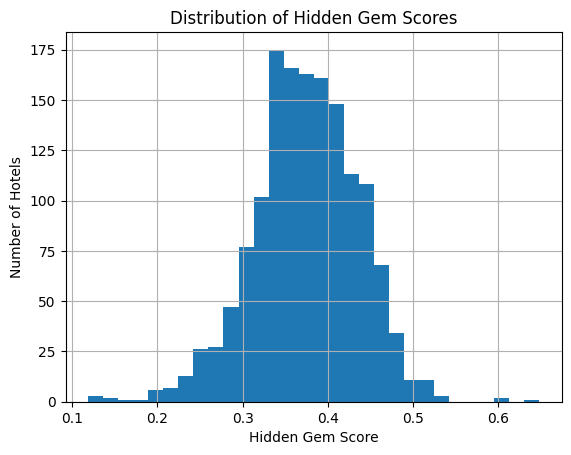

In [82]:
import matplotlib.pyplot as plt

hotel_stats["hidden_score_base"].hist(bins=30)

plt.title("Distribution of Hidden Gem Scores")
plt.xlabel("Hidden Gem Score")
plt.ylabel("Number of Hotels")
plt.savefig('../plot/Figure1_HiddenScoreDistribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Popularity vs Hidden Gem Score

Figure 2 supports the central project hypothesis: review volume and hidden-gem quality are not
identical. Many hotels with lower normalized review counts still achieve strong hidden-gem scores,
while highly reviewed hotels are not always the highest-scoring properties.

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    hotel_stats["dataset_total_reviews"],
    hotel_stats["hidden_score_base"],
    alpha=0.5
)

plt.xlabel("Total Reviews (Normalized)")
plt.ylabel("Hidden Gem Score")
plt.title("Popularity vs Hidden Gem Score")

plt.savefig('../plot/Figure2_PopularityVsHiddenScore.png', dpi=300, bbox_inches='tight')
plt.show()

### Average hidden-gem score of top hotels by city

Figure 3 compares the average hidden-gem score for top hotels by city. The pattern suggests that
hidden-gem opportunity differs across markets, with Paris standing out in the reporting sample.

In [ ]:
top_hotels = (
    hotel_stats
    .sort_values("hidden_score_base", ascending=False)
    .groupby("city")
    .head(5)
)

top_hotels.groupby("city")["hidden_score_base"].mean().plot(
    kind="bar"
)

plt.title("Average Hidden Gem Score of Top Hotels by City")
plt.ylabel("Hidden Gem Score")

plt.savefig('../plot/Figure3_TopHiddenGemsByCity.png', dpi=300, bbox_inches='tight')
plt.show()

### Impact of user preferences on Paris recommendations.

Figure 4 demonstrates that the recommender is not simply returning one static list. When
preference settings shift from quiet/calm to lively/crowded, most of the top ten recommendations
change, showing that personalization meaningfully affects ranking output.

In [ ]:
from textwrap import fill

# Quiet traveler scenario
quiet_results = recommend(
    hotel_stats,
    city="Paris",
    prefer_quiet=True,
    quiet_weight=0.30,
    avoid_crowds=True,
    crowd_weight=0.30,
    distance_mode="balanced",
    distance_weight=0.10,
    top_k=10
)

# Lively traveler scenario
lively_results = recommend(
    hotel_stats,
    city="Paris",
    prefer_quiet=False,
    quiet_weight=0.30,
    avoid_crowds=False,
    crowd_weight=0.30,
    distance_mode="balanced",
    distance_weight=0.10,
    top_k=10
)

# Create comparison table
figure4_df = pd.DataFrame({
    "Rank": range(1, 11),
    "Quiet Traveler": quiet_results["Hotel_Name"].tolist(),
    "Lively Traveler": lively_results["Hotel_Name"].tolist()
})

# Calculate overlap
quiet_set = set(quiet_results["Hotel_Name"])
lively_set = set(lively_results["Hotel_Name"])
overlap = len(quiet_set.intersection(lively_set))
changed = 10 - overlap

# Wrap long hotel names for readability
display_df = figure4_df.copy()
display_df["Quiet Traveler"] = display_df["Quiet Traveler"].apply(lambda x: fill(str(x), width=28))
display_df["Lively Traveler"] = display_df["Lively Traveler"].apply(lambda x: fill(str(x), width=28))

# Dynamic figure height
fig_height = 0.65 * len(display_df) + 2.2
fig, ax = plt.subplots(figsize=(14, fig_height))
ax.axis("off")

# Title
ax.set_title(
    "Impact of User Preferences on Paris Hotel Recommendations",
    fontsize=18,
    pad=20,
    weight="bold"
)

# Create table
table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc="left",
    colLoc="center",
    bbox=[0, 0.08, 1, 0.84]   # [left, bottom, width, height]
)

# Font and scale
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)

# Style cells
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(1.0)

    # Header row
    if row == 0:
        cell.set_text_props(weight="bold", color="black", ha="center")
        cell.set_facecolor("#D9EAF7")
    else:
        # Alternate row shading
        cell.set_facecolor("#F7F7F7" if row % 2 == 0 else "white")

        # Alignment
        if col == 0:
            cell.set_text_props(ha="center")
        else:
            cell.set_text_props(ha="left")

# Optional: adjust column widths manually
for row in range(len(display_df) + 1):
    table[(row, 0)].set_width(0.10)
    table[(row, 1)].set_width(0.45)
    table[(row, 2)].set_width(0.45)

# Footnote / takeaway
plt.figtext(
    0.5,
    0.02,
    f"{changed} of the top 10 recommendations changed when traveler preferences changed.",
    ha="center",
    fontsize=11,
    style="italic"
)

plt.savefig(
    "../plot/Figure4_UserPreferenceImpact.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"{changed} of the Top 10 recommendations changed when traveler preferences changed.")

In [29]:
hotel_stats.to_csv("../data/hotel_stats_final.csv", index=False)

## Notes for next step
Good next upgrades:
- Explore more LLM manipulation
- Extract actual city from lat/lng (instead of using metro are)
- Add airbnb dataset or google dataset
- Integrate with hotel pricing dataset for budget considerations
- Improve streamlit app